# NB03 — Staffing a critical week: Erlang C vs. the variability correction

## 1. The question

**In the worst observed week, how many on-call engineers do I need so that 90% of incidents start being handled within 30 minutes?**

That single sentence is the whole notebook. Everything below exists to turn it into a number — and, more importantly, into a *defensible range* with the assumptions on the table.

## 2. What the lead actually controls

The persona of this case study is the lead of a NOC/support team whose workload is partly generated by third-party cloud services (GitHub, Anthropic, Cloudflare, ...) that the team does not control. The lead controls exactly three things: staffing, internal SLOs, and triage policy. This notebook informs the first one.

The decision is concrete: how many engineers per on-call rotation? Google's SRE book gives a rule of thumb (minimum 8 people for 24/7 single-site coverage, driven by pager rotation sustainability, not by load). This notebook shows the *load-side* calculation behind such a recommendation for a small operation: the queueing-theory floor (Erlang C), the correction that real-world variability forces on it (Allen-Cunneen / Kingman), and the uncertainty band around both.

Two failure modes are equally expensive here. Understaffing means incidents queue unattended past the 30-minute mark — users notice, trust erodes. Overstaffing burns engineer-hours (and on-call sanity) on idle shifts. The textbook model and its correction disagree about where the line is; the gap between them is the finding.

## 3. Real data, and three honest limits

The source is `data/real/service_incidents.csv`: 787 incidents scraped from the public status pages of 18 cloud providers (v2 capture, expanded 2026-07-03), 774 of them with a resolved duration. This is real operational exhaust, not synthetic data, and three limits shape everything that follows from it.

The first is that each provider's status-page API returns roughly its last 50 incidents, and 50 incidents means something wildly different depending on how often a provider breaks: for Twilio that window covers about 9 days, for Atlassian about 7 years. Pool arrival counts across providers without correcting for this and quiet providers get silently credited with as much observation time as noisy ones. **Rule for this notebook: arrival rates are only computed on a common recent window, restricted to providers whose own window fully covers it** (the coverage check runs below, not asserted here).

The second is left-censorship: status pages publish incidents the provider chose to declare, so the λ estimated here is a rate of declared incidents, not of real failures. For a NOC consuming these services that is arguably the right object to measure (you get paged when the provider declares, or when your own monitoring catches what they will later declare), but it is a floor on the true failure rate, not the rate itself.

The third is that service time is a proxy. Time-to-resolution (TTR) stands in for the time an engineer is occupied per incident, when in reality an engineer working a vendor incident is mitigating, communicating and monitoring, not fixing the vendor's infrastructure — yet the incident does occupy attention for roughly its open duration. Treating full TTR as service time is a conservative, pessimistic assumption for staffing purposes, and it's declared here rather than smuggled in.

A separate synthetic dataset (`data/synthetic/synthetic_incidents.csv`, DORA-calibrated, generator parameters λ = 1.7 incidents/day and median MTTR 60 min, seed 20240401) shows up only once, at the end, as a labeled benchmark world, and it is never mixed with the real data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial, exp
from scipy import stats

rng = np.random.default_rng(20240401)

# --- palette / chart chrome (design-system placeholder palette) ---
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, BLUE_LIGHT, GRAY_BAR = "#2a78d6", "#9ec5f4", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 10, "axes.titlecolor": INK,
})

inc = pd.read_csv("data/real/service_incidents.csv")
for c in ["created_at", "resolved_at"]:
    inc[c] = pd.to_datetime(inc[c], utc=True, format="mixed")

print(f"{len(inc)} incidents, {inc['provider'].nunique()} providers, "
      f"{inc['duration_min'].notna().sum()} with duration")

windows = (inc.dropna(subset=["created_at"])
              .groupby("provider")["created_at"].agg(["min", "max", "count"]))
windows["window_days"] = ((windows["max"] - windows["min"]).dt.total_seconds() / 86400).round(1)
windows.sort_values("window_days")

787 incidents, 18 providers, 774 with duration


,min,max,count,window_days
provider,,,,
twilio,2026-06-24 11:45:09.080000+00:00,2026-07-02 18:53:02.070000+00:00,50,8.3
cloudflare,2026-06-11 15:39:21.823000+00:00,2026-07-03 01:10:20.460000+00:00,50,21.4
openai,2026-06-04 19:12:53+00:00,2026-07-01 03:38:18+00:00,25,26.4
claude_anthropic,2026-05-28 19:04:04.091000+00:00,2026-06-27 18:00:00+00:00,50,30.0
github,2026-04-23 19:28:42.976000+00:00,2026-06-27 14:02:52.169000+00:00,50,64.8
zoom,2026-04-28 06:08:40.183000+00:00,2026-07-02 10:23:36.547000+00:00,50,65.2
vercel,2026-03-31 13:10:16.253000+00:00,2026-07-02 16:31:55.765000+00:00,50,93.1
linear,2026-03-24 15:58:42+00:00,2026-06-30 20:12:59+00:00,25,98.2
digitalocean,2026-02-16 07:36:35.652000+00:00,2026-07-02 22:04:53.265000+00:00,50,136.6


The table confirms the problem: observation windows run from ~8 days (Twilio) to ~2,100 days (Atlassian). GCP appears with 3 incidents and no timestamps at all, so it is excluded from everything (consistent with the design doc's exclusion of GCP from duration analysis).

### Choosing the common window — coverage check

I need a window where (a) it is *recent* enough to describe today's provider mix, (b) it spans whole weeks (the question is about a peak *week*), and (c) as many providers as possible have their *entire* capture window covering it, so an incident inside the window is guaranteed observable for every included provider.

Two hard constraints bound the choice: `claude_anthropic`'s oldest retained incident is 2026-05-28 (its 50-incident buffer starts there), and the `github`/`claude_anthropic` captures end 2026-06-27. The longest run of whole weeks inside those bounds is **four weeks, 2026-05-31 → 2026-06-27 (Sunday–Saturday)**. Extending earlier drops Anthropic, a core dependency of the persona; extending later drops GitHub. The check below lists exactly which providers' windows contain it.

In [2]:
W0 = pd.Timestamp("2026-05-31", tz="UTC")
W1 = pd.Timestamp("2026-06-28", tz="UTC")   # exclusive end
N_DAYS, N_WEEKS = 28, 4

covers = windows[(windows["min"] <= W0) & (windows["max"] >= W1 - pd.Timedelta(days=1))]
covered_providers = sorted(covers.index)
partial = sorted(set(windows.index) - set(covered_providers))
print(f"Common window: {W0.date()} .. {(W1 - pd.Timedelta(days=1)).date()}  ({N_DAYS} days, {N_WEEKS} whole weeks)")
print(f"Providers whose OWN window fully covers it ({len(covered_providers)}): {covered_providers}")
print(f"Excluded (window does not cover it): {partial}")

sub = inc[inc["provider"].isin(covered_providers)
          & (inc["created_at"] >= W0) & (inc["created_at"] < W1)].copy()
print(f"\nIncidents in common window from covered providers: {len(sub)}")
print(sub["provider"].value_counts().to_string())

Common window: 2026-05-31 .. 2026-06-27  (28 days, 4 whole weeks)
Providers whose OWN window fully covers it (9): ['circleci', 'claude_anthropic', 'datadog', 'digitalocean', 'discord', 'github', 'linear', 'vercel', 'zoom']
Excluded (window does not cover it): ['atlassian', 'cloudflare', 'dropbox', 'figma', 'npm', 'openai', 'reddit', 'twilio']

Incidents in common window from covered providers: 132
provider
claude_anthropic    46
github              21
zoom                20
circleci            12
linear              10
vercel               9
datadog              6
digitalocean         6
discord              2


Nine providers fully cover the window: circleci, claude_anthropic, datadog, digitalocean, discord, github, linear, vercel, zoom. The other eight dated providers are excluded for opposite reasons: some because their buffer is too *short* to reach back to May 31 (twilio, cloudflare, openai), others because their buffer is so *long* that its newest incident predates the window (atlassian, reddit, dropbox, npm, figma) — exactly the heterogeneity that makes naive pooling wrong. One side effect is worth flagging: Twilio, the provider the design doc flagged as a probable correlated platform crisis (45 incidents in 9 days), falls outside the covered set, so its burst does not contaminate λ here.

This λ, then, is not a claim about the cloud's overall failure rate (no single window can support that claim, since it mixes providers with wildly different declaration habits); it is the arrival rate of declared incidents facing *a NOC consuming these nine services simultaneously*, a deliberately service-heavy stack but not an unusual one. That distinction is the whole difference between a number that describes the internet and a number that describes one team's exposure, which is the only number this notebook is trying to produce.

One thing worth flagging before this window travels any further: NB05 asks the same “what is the common window and its peak week” question and gets a different answer, an 11-provider panel over 2026-04-28 to 2026-06-08 with a 28-incident peak week (2026-05-05 to 2026-05-12). That is not an error to reconcile, it is two rules doing different jobs, each pre-registered before either notebook looked at the data: this one fixes recency first, bounded by the shortest-lived core dependency, and lets the panel size fall out to nine providers; NB05 fixes panel size first and lets the window stretch to 41.6 days to get it. A reader stacking the two notebooks should expect a different peak week out of each, and NB05's own note on this, §4.1's “The honest note on the real peak week,” is where that reasoning lives, not a discrepancy to chase down here.

## 4. Method and assumptions

The pipeline: (1) daily arrival counts on the common window → λ and the peak week; (2) an overdispersion test, executed rather than assumed, on those counts (Poisson assumption of Erlang C); (3) service-time mean and squared coefficient of variation c²ₛ recomputed from the duration data (same computation NB02 uses: c²ₛ = Var(TTR)/E[TTR]², so this notebook is self-contained); (4) Erlang C as the textbook floor; (5) the Allen-Cunneen/Kingman correction that consumes the *measured* c²ₐ and c²ₛ; (6) bootstrap and analytic uncertainty propagated to the recommended staffing level.

### 4.1 Daily arrivals and the peak week

In [3]:
days = pd.date_range(W0, periods=N_DAYS, freq="D")
daily = (sub["created_at"].dt.floor("D").value_counts()
         .reindex(days, fill_value=0).sort_index())
weekly = daily.groupby(np.arange(N_DAYS) // 7).sum()
week_starts = [days[i * 7].date() for i in range(N_WEEKS)]
peak_w = int(weekly.idxmax())
lam_all = daily.mean()                      # incidents/day, whole window
lam_peak_day = weekly.max() / 7             # incidents/day, peak week

print("Weekly totals:", dict(zip([str(w) for w in week_starts], weekly.tolist())))
print(f"Peak week: {week_starts[peak_w]} .. {days[peak_w*7+6].date()}  -> {weekly.max()} incidents")
print(f"lambda (whole window) = {lam_all:.2f}/day   lambda_peak = {lam_peak_day:.2f}/day")
pk = sub[(sub["created_at"] >= days[peak_w*7]) & (sub["created_at"] < days[peak_w*7] + pd.Timedelta(days=7))]
print("Peak-week impact mix:", pk["impact"].value_counts().to_dict())
print("Peak-week providers:", pk["provider"].value_counts().to_dict())

Weekly totals: {'2026-05-31': 29, '2026-06-07': 36, '2026-06-14': 33, '2026-06-21': 34}
Peak week: 2026-06-07 .. 2026-06-13  -> 36 incidents
lambda (whole window) = 4.71/day   lambda_peak = 5.14/day
Peak-week impact mix: {'minor': 25, 'major': 7, 'critical': 3, 'none': 1}
Peak-week providers: {'claude_anthropic': 14, 'github': 5, 'circleci': 5, 'zoom': 4, 'vercel': 2, 'datadog': 2, 'discord': 2, 'linear': 1, 'digitalocean': 1}


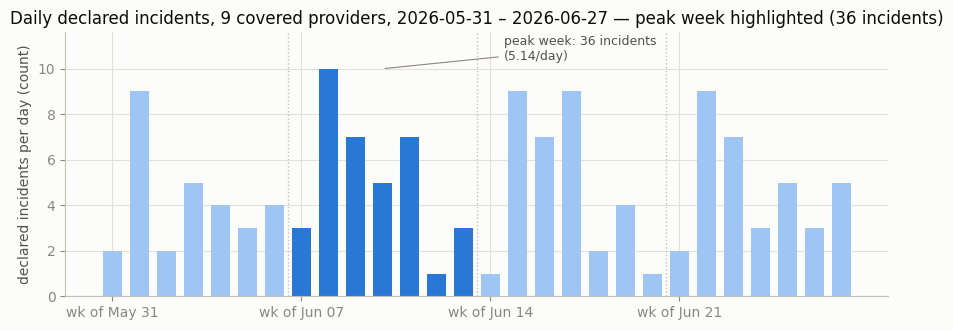

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.4))
in_peak = (np.arange(N_DAYS) // 7) == peak_w
colors = [BLUE if p else BLUE_LIGHT for p in in_peak]
ax.bar(range(N_DAYS), daily.values, color=colors, width=0.72)
for i in range(1, N_WEEKS):
    ax.axvline(i * 7 - 0.5, color=BASELINE, lw=1, ls=":")
ax.set_xticks(range(0, N_DAYS, 7),
              [f"wk of {w.strftime('%b %d')}" for w in week_starts])
ax.set_ylabel("declared incidents per day (count)")
ax.set_title(f"Daily declared incidents, 9 covered providers, {W0.date()} – {(W1 - pd.Timedelta(days=1)).date()}"
             f" — peak week highlighted ({weekly.max()} incidents)")
i_pk = int(np.argmax(in_peak))
ax.annotate(f"peak week: {weekly.max()} incidents\n({lam_peak_day:.2f}/day)",
            xy=(i_pk + 3, daily.values[in_peak].max()), xytext=(i_pk + 7.5, daily.values.max() + 0.4),
            color=INK2, fontsize=9,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax.set_ylim(0, daily.values.max() + 1.6)
plt.tight_layout()
plt.show()

The peak week is the second one (June 7–13, 36 incidents, ≈5.14/day vs. 4.71/day over the whole window). Its severity mix matters for interpretation and is printed above: mostly `minor`, consistent with the design doc's earlier observation that real peak weeks are gentler than hypothetical stress scenarios. Note also that weekly totals (29, 36, 33, 34) are strikingly *stable* — the "worst" week is only ~9% above the mean week. The drama is inside the days, not between the weeks.

### 4.2 Overdispersion test — is Poisson even tenable?

Erlang C assumes Poisson arrivals, which implies Var = Mean for daily counts (dispersion index = 1). Real incident arrivals are usually bursty: one platform problem spawns several declared incidents. The test statistic is (n−1)·(Var/Mean) ~ χ²(n−1) under Poisson.

In [5]:
n = len(daily)
disp = daily.var(ddof=1) / daily.mean()
chi2_stat = (n - 1) * disp
p_over = stats.chi2.sf(chi2_stat, n - 1)
print(f"Daily counts: mean = {daily.mean():.2f}, var = {daily.var(ddof=1):.2f}")
print(f"Dispersion index var/mean = {disp:.2f}  (Poisson => 1)")
print(f"Chi-square dispersion test: stat = {chi2_stat:.1f}, df = {n-1}, one-sided p = {p_over:.3f}")
ca2 = disp   # empirical squared CV of arrivals, approximated by the dispersion index
print(f"=> arrivals are overdispersed; we take c_a^2 ≈ {ca2:.2f}")

Daily counts: mean = 4.71, var = 7.77
Dispersion index var/mean = 1.65  (Poisson => 1)
Chi-square dispersion test: stat = 44.5, df = 27, one-sided p = 0.018
=> arrivals are overdispersed; we take c_a^2 ≈ 1.65


**Var/Mean = 1.65, p ≈ 0.02**: the Poisson assumption fails, in the direction the design doc anticipated (the reviewer measured 1.83 on the pre-expansion data; on the expanded common window it lands at 1.65, the same conclusion: arrivals are bursty). Overdispersed arrivals produce longer queues than Poisson at the same mean rate, so pure Erlang C will read as optimistic, and that is exactly why the Allen-Cunneen correction below is not optional. I carry the dispersion index forward as the empirical squared coefficient of variation of arrivals, c²ₐ ≈ 1.65 (an approximation, since the dispersion index of counts equals c²ₐ of inter-arrival times exactly only for renewal processes at long time scales, which I declare rather than gloss over).

### 4.3 Service time: mean, and c²ₛ recomputed as in NB02

I recompute c²ₛ = Var(TTR)/E[TTR]² directly from the durations of the common-window incidents (the same population whose arrivals define λ, using the same formula NB02 applies per provider). One sensitivity check, executed rather than assumed: the single most extreme duration.

In [6]:
dur = sub["duration_min"].dropna().values
S = dur.mean()                       # mean service time, minutes
cs2 = dur.var(ddof=1) / S**2         # squared CV of service time (as in NB02)
print(f"n = {len(dur)} durations in window "
      f"({len(sub) - len(dur)} unresolved/no duration excluded)")
print(f"mean TTR = {S:.1f} min   median TTR = {np.median(dur):.1f} min   "
      f"p95 = {np.quantile(dur, 0.95):.1f} min")
print(f"c_s^2 = {cs2:.2f}")

imax = dur.argmax()
worst = sub.dropna(subset=["duration_min"]).nlargest(1, "duration_min")
print(f"\nSingle most extreme duration: {dur[imax]:.0f} min "
      f"({dur[imax]/1440:.1f} days) — {worst['provider'].iloc[0]}: {worst['name'].iloc[0]!r}")
dur_trim = np.delete(dur, imax)
S_trim = dur_trim.mean()
cs2_trim = dur_trim.var(ddof=1) / S_trim**2
print(f"Without that one incident: mean TTR = {S_trim:.1f} min, c_s^2 = {cs2_trim:.2f}")

n = 131 durations in window (1 unresolved/no duration excluded)
mean TTR = 156.1 min   median TTR = 61.3 min   p95 = 401.0 min
c_s^2 = 13.47

Single most extreme duration: 6515 min (4.5 days) — zoom: 'Service Degradation Affecting Zoom Meeting Recordings'
Without that one incident: mean TTR = 107.2 min, c_s^2 = 1.30


This is the most consequential number in the notebook. **c²ₛ = 13.5 — but a single incident carries almost all of it**: one Zoom recording-degradation incident stayed open 6,515 minutes, 4.5 days. Drop that one row and c²ₛ collapses to 1.30, and the mean falls from 156 to 107 minutes. The mean/median gap, 156 versus 61 minutes, tells the same story: service times are heavy-tailed, consistent with NB02's log-normal analysis.

I do not delete the incident. Multi-day vendor incidents are real, and a staffing model that assumes them away is lying about the world it claims to describe. Instead I carry both readings, with and without, through the bootstrap, where resamples that happen to miss the outlier naturally produce the trimmed world on their own. The point estimate uses the full data.

The caveat from the data section applies with force here: an engineer probably does not actively work a 4.5-day vendor incident for 4.5 days straight. TTR-as-service-time is most wrong exactly in the tail — conservative, and declared as such, not hidden in a footnote.

In [7]:
def erlang_c(c: int, a: float) -> float:
    """Erlang C delay probability, direct textbook formula."""
    if a >= c:
        return 1.0
    tail = (a**c / factorial(c)) * (c / (c - a))
    return tail / (sum(a**k / factorial(k) for k in range(c)) + tail)

def p_wait_gt(c: int, a: float, t: float, mean_s: float, f: float = 1.0) -> float:
    """P(wait > t). f=1 -> Erlang C (M/M/c); f=(ca2+cs2)/2 -> Allen-Cunneen heuristic."""
    if a >= c:
        return 1.0
    return erlang_c(c, a) * exp(-(c - a) * t / (f * mean_s))

def min_servers(a: float, t: float, mean_s: float, f: float = 1.0,
                target: float = 0.10) -> int:
    return next(c for c in range(1, 50) if p_wait_gt(c, a, t, mean_s, f) <= target)

T_SL = 30.0                                  # service-level threshold, minutes
lam_min = lam_peak_day / 1440.0              # arrivals per minute, peak week
a_real = lam_min * S                         # offered load, erlangs
f_real = (ca2 + cs2) / 2

# --- DORA synthetic world: DIFFERENT WORLD, generator parameter lambda = 1.7/day ---
syn = pd.read_csv("data/synthetic/synthetic_incidents.csv")
dur_syn = syn["duration_min"].dropna().values
S_dora = dur_syn.mean()
LAM_DORA = 1.7                               # DECLARED generator parameter, not estimated
a_dora = LAM_DORA / 1440.0 * S_dora

print(f"Observed world:  lambda_peak = {lam_peak_day:.2f}/day, E[S] = {S:.1f} min, "
      f"a = {a_real:.3f} erlangs, f = (ca2 + cs2)/2 = ({ca2:.2f} + {cs2:.2f})/2 = {f_real:.2f}")
print(f"DORA world:      lambda = {LAM_DORA}/day (generator param), E[S] = {S_dora:.1f} min, "
      f"a = {a_dora:.3f} erlangs\n")

rows = []
for c in range(1, 7):
    rows.append({
        "c (engineers)": c,
        "Erlang C  P(W>30min)": p_wait_gt(c, a_real, T_SL, S),
        "Allen-Cunneen  P(W>30min)": p_wait_gt(c, a_real, T_SL, S, f_real),
        "DORA-synthetic  P(W>30min)": p_wait_gt(c, a_dora, T_SL, S_dora),
    })
table = pd.DataFrame(rows).set_index("c (engineers)")
c_ec = min_servers(a_real, T_SL, S)
c_ac = min_servers(a_real, T_SL, S, f_real)
c_dora = min_servers(a_dora, T_SL, S_dora)
print(table.round(4).to_string())
print(f"\nMinimum c for P(W>30min) <= 10%:  Erlang C -> c = {c_ec}   "
      f"Allen-Cunneen -> c = {c_ac}   DORA world -> c = {c_dora}")

Observed world:  lambda_peak = 5.14/day, E[S] = 156.1 min, a = 0.557 erlangs, f = (ca2 + cs2)/2 = (1.65 + 13.47)/2 = 7.56
DORA world:      lambda = 1.7/day (generator param), E[S] = 92.2 min, a = 0.109 erlangs

               Erlang C  P(W>30min)  Allen-Cunneen  P(W>30min)  DORA-synthetic  P(W>30min)
c (engineers)                                                                             
1                            0.5120                     0.5512                      0.0814
2                            0.0921                     0.1171                      0.0030
3                            0.0127                     0.0191                      0.0001
4                            0.0014                     0.0025                      0.0000
5                            0.0001                     0.0003                      0.0000
6                            0.0000                     0.0000                      0.0000

Minimum c for P(W>30min) <= 10%:  Erlang C -> c = 2   Allen-

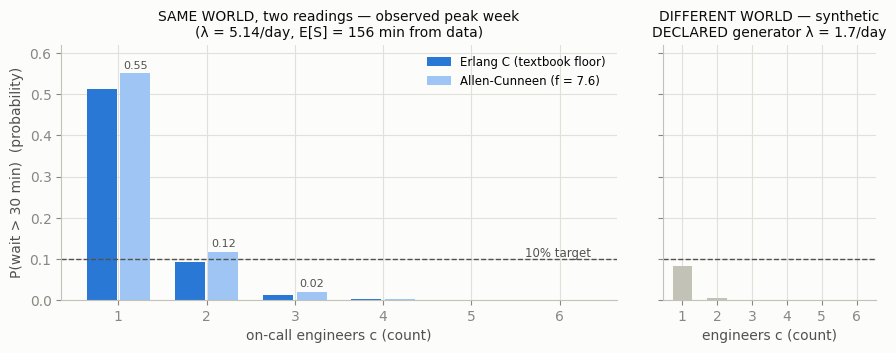

In [8]:
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(9, 3.8), sharey=True,
    gridspec_kw={"width_ratios": [3, 1.15], "wspace": 0.12})

cs = np.arange(1, 7)
w = 0.38
ec_vals = table["Erlang C  P(W>30min)"].values
ac_vals = table["Allen-Cunneen  P(W>30min)"].values
axL.bar(cs - w/2, ec_vals, width=w - 0.04, color=BLUE, label="Erlang C (textbook floor)")
axL.bar(cs + w/2, ac_vals, width=w - 0.04, color=BLUE_LIGHT,
        label=f"Allen-Cunneen (f = {f_real:.1f})")
axL.axhline(0.10, color=INK2, lw=1, ls="--")
axL.text(6.35, 0.105, "10% target", color=INK2, fontsize=8.5, ha="right")
for c, v in zip(cs, ac_vals):
    if v > 0.005:
        axL.text(c + w/2, v + 0.012, f"{v:.2f}", ha="center", color=INK2, fontsize=8)
axL.set_title(f"SAME WORLD, two readings — observed peak week\n"
              f"(λ = {lam_peak_day:.2f}/day, E[S] = {S:.0f} min from data)", fontsize=10)
axL.set_xlabel("on-call engineers c (count)")
axL.set_ylabel("P(wait > 30 min)  (probability)")
axL.legend(frameon=False, fontsize=8.5)

dora_vals = table["DORA-synthetic  P(W>30min)"].values
axR.bar(cs, dora_vals, width=0.55, color=GRAY_BAR)
axR.axhline(0.10, color=INK2, lw=1, ls="--")
axR.set_title("DIFFERENT WORLD — synthetic\nDECLARED generator λ = 1.7/day", fontsize=10)
axR.set_xlabel("engineers c (count)")
for ax in (axL, axR):
    ax.set_xticks(cs)
    ax.set_ylim(0, 0.62)
fig.subplots_adjust(left=0.08, right=0.985, top=0.82, bottom=0.15)
plt.show()

The textbook floor says c = 2 clears the target, barely: P(W>30) = 0.092, a 0.8-point margin under the 10% ceiling. Feed the measured variability into the same-world correction, though, and c = 2 fails at 0.117 — Allen-Cunneen says c = 3. The gap between the two columns is exactly the finding the design doc asked for: the book says 2, the measured burstiness says 3, and since both the overdispersion (§4.2) and the heavy service tail (§4.3) are independently confirmed rather than assumed, the corrected column is the one I believe. The correction is modest in absolute terms only because the offered load is low, a ≈ 0.56 erlangs: most of the time even one engineer is idle, and the whole question is about what happens in the rare moments two incidents collide.

The right panel is drawn apart on purpose, and for a reason worth stating plainly: it isn't a third line of evidence about our world, because its arrival rate, λ = 1.7/day, is a generator parameter I declared rather than measured, DORA-calibrated with seed 20240401, and it is a different, synthetic world, useful only as a landmark to locate where the observed operation sits. A DORA-median team consuming one aggregate service stream at that rate would clear the target with a single engineer. This nine-provider stack at peak runs three times that arrival rate, which is the whole reason c = 1 was never on the table here.

## 5. Result — with uncertainty

### 5.1 Why the point estimate cannot be trusted as-is

"The worst observed week" is an extreme order statistic over only 4 weeks. Two problems: (a) sampling noise: 36 arrivals is a small count; (b) regression to the mean: the maximum of a small sample systematically overshoots the process's typical rate, so re-running history would usually produce a milder "worst week". I quantify (a) two ways and declare (b) as an unquantified upward bias that makes the staffing recommendation conservative.

**Bootstrap design, pre-declared:** a naive iid bootstrap of the peak week's own 7 days would understate uncertainty, since it conditions on the week already being extreme. Instead, the resampling unit is days grouped by day-of-week across the 4 available weeks: each replicate rebuilds 4 synthetic weeks by drawing, for every day-of-week, one of that weekday's 4 observed counts, then takes the maximum weekly total, reproducing the "worst of 4 weeks" selection. Day-of-week grouping preserves any weekday/weekend structure. Cross-check: the exact (chi-square) Poisson CI on the observed peak count of 36. Service-time uncertainty comes from an iid bootstrap of the 131 durations, recomputing E[S] and c²ₛ per replicate. B = 10,000, seed 20240401.

In [9]:
B = 10_000
dow = daily.index.dayofweek.values
counts_by_dow = {d: daily.values[dow == d] for d in range(7)}

boot_lam_peak = np.empty(B)
boot_c_ec = np.empty(B, dtype=int)
boot_c_ac = np.empty(B, dtype=int)
for b in range(B):
    weeks_b = np.array([[rng.choice(counts_by_dow[d]) for d in range(7)]
                        for _ in range(N_WEEKS)]).sum(axis=1)
    lam_b = weeks_b.max() / 7
    boot_lam_peak[b] = lam_b
    dur_b = rng.choice(dur, size=len(dur), replace=True)
    S_b = dur_b.mean()
    cs2_b = dur_b.var(ddof=1) / S_b**2
    a_b = lam_b / 1440.0 * S_b
    boot_c_ec[b] = min_servers(a_b, T_SL, S_b)
    boot_c_ac[b] = min_servers(a_b, T_SL, S_b, (ca2 + cs2_b) / 2)

lam_ci = np.percentile(boot_lam_peak, [2.5, 97.5])
k = int(weekly.max())
pois_lo = 0.5 * stats.chi2.ppf(0.025, 2 * k) / 7
pois_hi = 0.5 * stats.chi2.ppf(0.975, 2 * (k + 1)) / 7
print(f"Bootstrap lambda_peak: median {np.median(boot_lam_peak):.2f}/day, "
      f"95% CI [{lam_ci[0]:.2f}, {lam_ci[1]:.2f}]/day")
print(f"Analytic Poisson 95% CI on peak-week count {k}: "
      f"[{pois_lo*7:.1f}, {pois_hi*7:.1f}] incidents -> [{pois_lo:.2f}, {pois_hi:.2f}]/day")

dist_ec = np.bincount(boot_c_ec, minlength=6)[:6] / B
dist_ac = np.bincount(boot_c_ac, minlength=6)[:6] / B
print("\nBootstrap distribution of the minimum adequate c:")
print(pd.DataFrame({"Erlang C": dist_ec[1:], "Allen-Cunneen": dist_ac[1:]},
                   index=pd.Index(range(1, 6), name="c")).round(3).to_string())

Bootstrap lambda_peak: median 5.29/day, 95% CI [4.57, 6.14]/day
Analytic Poisson 95% CI on peak-week count 36: [25.2, 49.8] incidents -> [3.60, 7.12]/day

Bootstrap distribution of the minimum adequate c:
   Erlang C  Allen-Cunneen
c                         
1     0.000          0.000
2     0.575          0.420
3     0.414          0.561
4     0.010          0.019
5     0.000          0.000


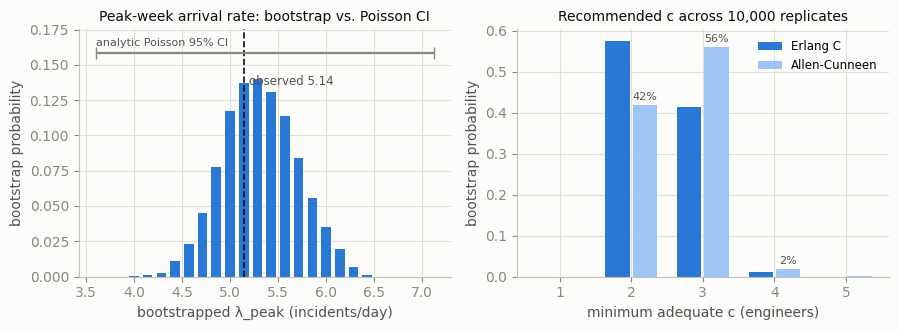

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.4))

vals, cnts = np.unique(boot_lam_peak, return_counts=True)
pmax = max(cnts / B)
ax1.bar(vals, cnts / B, width=0.10, color=BLUE)
ax1.axvline(lam_peak_day, color=INK, lw=1.2, ls="--")
ax1.text(lam_peak_day + 0.05, pmax * 0.97,
         f"observed {lam_peak_day:.2f}", color=INK2, fontsize=8.5)
y_ci = pmax * 1.13
ax1.errorbar([(pois_lo + pois_hi) / 2], [y_ci],
             xerr=[[(pois_hi - pois_lo) / 2]], fmt="none",
             ecolor=MUTED, elinewidth=1.6, capsize=4)
ax1.text(pois_lo, y_ci + pmax * 0.035,
         "analytic Poisson 95% CI", ha="left", color=INK2, fontsize=8)
ax1.set_ylim(0, pmax * 1.25)
ax1.set_xlabel("bootstrapped λ_peak (incidents/day)")
ax1.set_ylabel("bootstrap probability")
ax1.set_title("Peak-week arrival rate: bootstrap vs. Poisson CI", fontsize=10)

x = np.arange(1, 6)
w = 0.38
ax2.bar(x - w/2, dist_ec[1:], width=w - 0.04, color=BLUE, label="Erlang C")
ax2.bar(x + w/2, dist_ac[1:], width=w - 0.04, color=BLUE_LIGHT, label="Allen-Cunneen")
for xi, v in zip(x, dist_ac[1:]):
    if v > 0.01:
        ax2.text(xi + w/2, v + 0.012, f"{v:.0%}", ha="center", color=INK2, fontsize=8)
ax2.set_xticks(x)
ax2.set_xlabel("minimum adequate c (engineers)")
ax2.set_ylabel("bootstrap probability")
ax2.set_title("Recommended c across 10,000 replicates", fontsize=10)
ax2.legend(frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()

The bootstrap puts λ_peak at [4.57, 6.14] per day; the analytic Poisson CI on the observed count of 36 is wider, [3.60, 7.12] per day, and that is expected: the day-of-week bootstrap cannot generate daily counts outside the observed support of four values per weekday, while the Poisson interval allows counts that were never actually seen. I treat the union of the two as the honest λ band. Propagated through both queueing models together with the duration bootstrap, the minimum adequate staffing distributes as printed above: under Erlang C, c = 2 in about 58% of replicates and c = 3 in about 41%; under Allen-Cunneen the mass flips, c = 3 in about 56% with a 2% tail reaching c = 4. The c = 2 replicates that survive under Allen-Cunneen are mostly resamples that missed the single 4.5-day Zoom incident from §4.3 — worlds, in other words, where the tail event simply never happened.

### 5.2 The recommendation — a range, not a point

$$\boxed{c = 2\text{–}4,\ \text{plan for } c = 3}$$

Each end of that range earns its place for a different reason. c = 2 is defensible only if you trust the textbook model *and* believe multi-day vendor incidents won't recur — and the data contradicts both of those beliefs at once, since overdispersion is confirmed and the tail event already happened. c = 3 is the modal Allen-Cunneen answer, clearing the target with margin under the point estimates, which is why it is the plan, not just a point in the range. c = 4 sits at the upper edge, demanded only occasionally, when the Poisson CI's upper λ (7.12/day) combines with a tail-heavy duration resample, and a documented escalation path to a fourth responder covers that scenario more cheaply than a fourth permanent seat would. Pulling the other way, regression to the mean argues that the next worst week is probably milder than 36 incidents, which is why the upper half of the range is insurance against a bad week, not an expectation about a typical one.

### 5.3 The nonlinearity — what removing one engineer costs

In [11]:
print(f"At the recommended c = {c_ac} (Allen-Cunneen reading, peak-week load):\n")
for c in (c_ac, c_ac - 1, c_ac - 2):
    p_ec = p_wait_gt(c, a_real, T_SL, S)
    p_ac = p_wait_gt(c, a_real, T_SL, S, f_real)
    pd_ = erlang_c(c, a_real)
    wq_ac = f_real * pd_ * S / (c - a_real)           # Allen-Cunneen mean queue wait
    print(f"c = {c}:  P(delayed) = {pd_:5.1%}   P(W>30min) EC = {p_ec:6.2%}  AC = {p_ac:6.2%}"
          f"   mean wait (AC) = {wq_ac:6.1f} min")

drop32 = p_wait_gt(c_ac - 1, a_real, T_SL, S, f_real) / p_wait_gt(c_ac, a_real, T_SL, S, f_real)
drop21 = p_wait_gt(c_ac - 2, a_real, T_SL, S, f_real) / p_wait_gt(c_ac - 1, a_real, T_SL, S, f_real)
print(f"\nRemoving one engineer from c=3 multiplies P(W>30min) by {drop32:.1f}x; "
      f"one more, by another {drop21:.1f}x.")

At the recommended c = 3 (Allen-Cunneen reading, peak-week load):

c = 3:  P(delayed) =  2.0%   P(W>30min) EC =  1.27%  AC =  1.91%   mean wait (AC) =    9.8 min
c = 2:  P(delayed) = 12.1%   P(W>30min) EC =  9.21%  AC = 11.71%   mean wait (AC) =   99.4 min
c = 1:  P(delayed) = 55.7%   P(W>30min) EC = 51.20%  AC = 55.12%   mean wait (AC) = 1486.3 min

Removing one engineer from c=3 multiplies P(W>30min) by 6.1x; one more, by another 4.7x.


Queues do not degrade linearly. Going from 3 engineers to 2 multiplies the probability of a 30-minute-plus wait by about 6×, from 1.9% to 11.7% through the miss threshold; going from 2 to 1 multiplies it again by about 5×, to 55% — a coin flip that an incident sits unattended for half an hour, with a mean queue wait of roughly a full day (≈1,486 min), because a single responder saturates the moment a long incident collides with a new arrival. The last engineer you cut is never one third of the capacity. They are the entire buffer against collisions. This is the VUT equation made concrete: wait scales with utilization *and* variability, and both punish the under-staffed tail disproportionately.

## 6. What I would actually do with this

Staff three on-call for peak conditions, not two. The textbook answer sits inside its own error bar of failure: it misses the target the moment measured variability enters the picture, and its already-thin 0.8-point margin evaporates under any λ in the upper half of the confidence interval. I would buy the fourth seat as an escalation path rather than a standing rotation: the c = 4 scenarios only show up in tail-of-CI worlds, and a documented "second pager" covers them at a fraction of the cost of a fourth permanent seat.

Multi-day vendor incidents deserve to be treated as their own work class, not folded into the general TTR distribution as if they were unusually long ordinary incidents. A single 4.5-day incident dominates c²ₛ, and that concentration points to an operational lever: a hand-off protocol where a long-running vendor incident moves to a background "monitor and communicate" mode after some threshold, which would shrink the effective service time, and with it the true staffing need, below what this conservative model recommends. That reshaping of service time is NB05's territory, the cμ-rule.

None of this is a number to set once. λ here is a four-week snapshot of nine providers, and adding one noisy dependency (the Twilio caveat lurking at the edge of the covered set) or living through one more provider platform crisis could move λ_peak by more than the width of the entire confidence interval. If I had to commit to a single operational habit coming out of this notebook, it would be re-running this estimate quarterly rather than trusting a number computed once in June to still describe the team's exposure in December.

## 7. Where this data runs out

λ counts *declared* incidents on public status pages, and providers under-declare, so the real interruption rate hitting a NOC is higher than what's measured here, by an unknowable factor. TTR is the provider's own resolution time, not an engineer's handling time: using it as a conservative proxy means the model over-states the need in the tail (nobody hand-works a 4.5-day incident continuously) while possibly under-stating it at the very start, where the first 30 minutes of a major incident can plausibly need two people, not one. Erlang-type models also assume incidents are independent work items, and a cloud-provider platform crisis breaks that assumption in two opposite directions at once: one engineer may triage a cluster of correlated incidents as a single batch, so arrival counts overstate distinct work, or the same cluster may swamp every channel simultaneously, so counts understate the coordination load. Four weeks of data cannot tell which direction dominates, and neither can distinguish "June is typical" from "June happened to be quiet": the window itself was forced by the shortest provider buffer, Anthropic's roughly 30-day, 50-incident retention, and a longer capture with stable provider coverage is the single highest-value data improvement available for this question. Finally, none of this reaches a 24/7 rotation's human constraints — three concurrent responders during a peak week says nothing about the eight-plus people needed to sustain that coverage across shifts, which is Google SRE's rostering number, not a queueing one, and belongs to a different kind of argument than the one this notebook makes.